In [3]:
import pandas as pd

df = pd.read_csv("../data/fake_job_postings.csv")

print("Dataset Loaded Successfully!")
print(df.shape)
df.head()

Dataset Loaded Successfully!
(17880, 18)


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
# Dataset ki basic information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   job_id               17880 non-null  int64
 1   title                17880 non-null  str  
 2   location             17534 non-null  str  
 3   department           6333 non-null   str  
 4   salary_range         2868 non-null   str  
 5   company_profile      14572 non-null  str  
 6   description          17879 non-null  str  
 7   requirements         15184 non-null  str  
 8   benefits             10668 non-null  str  
 9   telecommuting        17880 non-null  int64
 10  has_company_logo     17880 non-null  int64
 11  has_questions        17880 non-null  int64
 12  employment_type      14409 non-null  str  
 13  required_experience  10830 non-null  str  
 14  required_education   9775 non-null   str  
 15  industry             12977 non-null  str  
 16  function             11425 non-nu

In [5]:
# Missing values check

df.isnull().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

In [6]:
# Fake aur Real jobs ka distribution

df["fraudulent"].value_counts()

fraudulent
0    17014
1      866
Name: count, dtype: int64

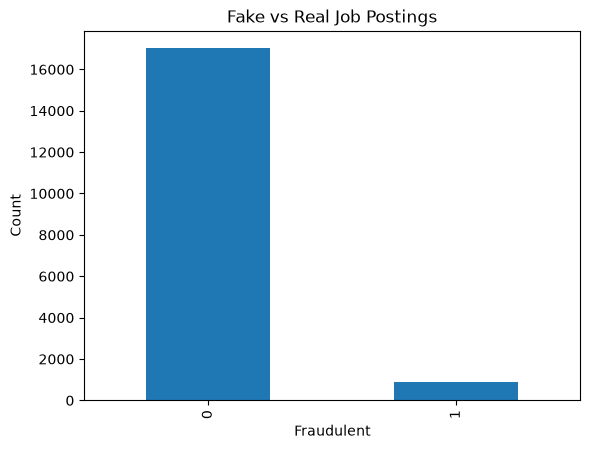

In [7]:
import matplotlib.pyplot as plt

df["fraudulent"].value_counts().plot(kind="bar")

plt.title("Fake vs Real Job Postings")
plt.xlabel("Fraudulent")
plt.ylabel("Count")
plt.show()

In [9]:
df.isnull().sum().sort_values(ascending=False)

salary_range           15012
department             11547
required_education      8105
benefits                7212
required_experience     7050
function                6455
industry                4903
employment_type         3471
company_profile         3308
requirements            2696
location                 346
description                1
title                      0
job_id                     0
telecommuting              0
has_questions              0
has_company_logo           0
fraudulent                 0
dtype: int64

In [10]:
missing = (df.isnull().sum() / len(df)) * 100
missing = missing.sort_values(ascending=False)

print(missing)

salary_range           83.959732
department             64.580537
required_education     45.329978
benefits               40.335570
required_experience    39.429530
function               36.101790
industry               27.421700
employment_type        19.412752
company_profile        18.501119
requirements           15.078300
location                1.935123
description             0.005593
title                   0.000000
job_id                  0.000000
telecommuting           0.000000
has_questions           0.000000
has_company_logo        0.000000
fraudulent              0.000000
dtype: float64


In [11]:
# Unnecessary columns remove karna

df = df.drop(columns=["salary_range", "department", "benefits"])

print("New Shape:", df.shape)

New Shape: (17880, 15)


In [12]:
# Text columns ko combine karna

df["text"] = (
    df["title"].fillna("") + " " +
    df["company_profile"].fillna("") + " " +
    df["description"].fillna("") + " " +
    df["requirements"].fillna("")
)

print(df["text"].head())

0    Marketing Intern We're Food52, and we've creat...
1    Customer Service - Cloud Video Production 90 S...
2    Commissioning Machinery Assistant (CMA) Valor ...
3    Account Executive - Washington DC Our passion ...
4    Bill Review Manager SpotSource Solutions LLC i...
Name: text, dtype: str


In [13]:
import re

def clean_text(text):
    text = text.lower()                     # Lowercase
    text = re.sub(r'http\S+', '', text)     # URLs remove
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Numbers & symbols remove
    text = re.sub(r'\s+', ' ', text)        # Extra spaces remove
    return text.strip()

df["clean_text"] = df["text"].apply(clean_text)

print(df["clean_text"].head())

0    marketing intern were food and weve created a ...
1    customer service cloud video production second...
2    commissioning machinery assistant cma valor se...
3    account executive washington dc our passion fo...
4    bill review manager spotsource solutions llc i...
Name: clean_text, dtype: str


In [14]:
df[['text', 'clean_text']].head()

,text,clean_text
0,"Marketing Intern We're Food52, and we've creat...",marketing intern were food and weve created a ...
1,Customer Service - Cloud Video Production 90 S...,customer service cloud video production second...
2,Commissioning Machinery Assistant (CMA) Valor ...,commissioning machinery assistant cma valor se...
3,Account Executive - Washington DC Our passion ...,account executive washington dc our passion fo...
4,Bill Review Manager SpotSource Solutions LLC i...,bill review manager spotsource solutions llc i...


In [15]:
import nltk

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\katiy\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\katiy\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\katiy\AppData\Roaming\nltk_data...


True

In [16]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [17]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [18]:
def preprocess(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]
    words = [lemmatizer.lemmatize(word) for word in words]
    return " ".join(words)

In [19]:
df["processed_text"] = df["clean_text"].apply(preprocess)

In [20]:
df[["clean_text", "processed_text"]].head()

,clean_text,processed_text
0,marketing intern were food and weve created a ...,marketing intern food weve created groundbreak...
1,customer service cloud video production second...,customer service cloud video production second...
2,commissioning machinery assistant cma valor se...,commissioning machinery assistant cma valor se...
3,account executive washington dc our passion fo...,account executive washington dc passion improv...
4,bill review manager spotsource solutions llc i...,bill review manager spotsource solution llc gl...


In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [22]:
tfidf = TfidfVectorizer(max_features=5000)

In [23]:
X = tfidf.fit_transform(df["processed_text"])

In [24]:
y = df["fraudulent"]

In [25]:
print(X.shape)

(17880, 5000)


In [26]:
print(y.value_counts())

fraudulent
0    17014
1      866
Name: count, dtype: int64


In [27]:
from sklearn.model_selection import train_test_split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
print(X_train.shape)
print(X_test.shape)

(14304, 5000)
(3576, 5000)


In [30]:
print(y_train.value_counts())
print(y_test.value_counts())

fraudulent
0    13611
1      693
Name: count, dtype: int64
fraudulent
0    3403
1     173
Name: count, dtype: int64


In [31]:
from sklearn.linear_model import LogisticRegression

In [32]:
model = LogisticRegression(max_iter=1000)

In [33]:
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [34]:
y_pred = model.predict(X_test)

In [35]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9723154362416108


In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      3403
           1       1.00      0.43      0.60       173

    accuracy                           0.97      3576
   macro avg       0.99      0.71      0.79      3576
weighted avg       0.97      0.97      0.97      3576



In [37]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[3403    0]
 [  99   74]]


In [38]:
from sklearn.naive_bayes import MultinomialNB

In [39]:
nb_model = MultinomialNB()

In [40]:
nb_model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[13611., 693.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.05,-3.03]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 5000)","[[ 3.18,16.11,12.56,..., 8.81, 2.96, 9.81], [ 0. , 0.41, 0. ,..., 0.2 , 0. , 0. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 5000)","[[-10.34, -8.93, -9.17,..., -9.49,-10.4 , -9.39], [ -9.25, -8.91, -9.25,..., -9.07, -9.25, -9.25]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5000


In [41]:
nb_pred = nb_model.predict(X_test)

In [42]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, nb_pred))

Accuracy: 0.9672818791946308


In [43]:
from sklearn.metrics import classification_report

print(classification_report(y_test, nb_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3403
           1       1.00      0.32      0.49       173

    accuracy                           0.97      3576
   macro avg       0.98      0.66      0.74      3576
weighted avg       0.97      0.97      0.96      3576



In [44]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, nb_pred))

[[3403    0]
 [ 117   56]]


In [45]:
from sklearn.ensemble import RandomForestClassifier

In [46]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [47]:
rf_model.fit(X_train, y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [48]:
rf_pred = rf_model.predict(X_test)

In [49]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, rf_pred))

Accuracy: 0.9823825503355704


In [50]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3403
           1       1.00      0.64      0.78       173

    accuracy                           0.98      3576
   macro avg       0.99      0.82      0.88      3576
weighted avg       0.98      0.98      0.98      3576



In [51]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, rf_pred))

[[3403    0]
 [  63  110]]


In [52]:
from sklearn.metrics import accuracy_score
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.972315
1,Naive Bayes,0.967282
2,Random Forest,0.982383


In [54]:
results = results.sort_values(
    by="Accuracy",
    ascending=False
)

results.reset_index(drop=True, inplace=True)

results

,Model,Accuracy
0,Random Forest,0.982383
1,Logistic Regression,0.972315
2,Naive Bayes,0.967282


In [55]:
import joblib

In [56]:
joblib.dump(model, "../models/fake_job_model.pkl")

['../models/fake_job_model.pkl']

In [57]:
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")

['../models/tfidf_vectorizer.pkl']

In [58]:
loaded_model = joblib.load("../models/fake_job_model.pkl")

loaded_vectorizer = joblib.load("../models/tfidf_vectorizer.pkl")

In [59]:
sample = [
    "Urgent hiring for Data Analyst with high salary. Apply now."
]

sample = loaded_vectorizer.transform(sample)

prediction = loaded_model.predict(sample)

print(prediction)

[0]


In [60]:
import joblib

joblib.dump(model, "../models/fake_job_model.pkl")
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")

['../models/tfidf_vectorizer.pkl']